Starting with a Simple Model for Baseline Performance

In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 5.4 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=5b530bfba5ed983474fcfc39314dcbaa2993b5fcf50189700f9afd07b02c0ea4
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
import xgboost as xgb
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split

In [ ]:
train_file_path = "1yVTNHjwM4hUbv0alTfW9hEn1itOVbHLg"
test_file_path = "1-1NGzpvsdLcBPFZU_aNOZYn-1BIMoWO2"
train_url = f"https://drive.google.com/uc?export=download&id={train_file_path}"
test_url = f"https://drive.google.com/uc?export=download&id={test_file_path}"
train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

In [ ]:
train_df = train_df.drop('gvhd_proph_FK+- others(not MMF,MTX)', axis=1)
#print(train_df.columns)

In [ ]:
# Fit the Cox Proportional Hazards model
cph = CoxPHFitter(penalizer = 0.1)
cph.fit(train_df, duration_col='efs_time', event_col='efs')

# The model will provide a summary of coefficients
print(cph.summary)

# Get the risk scores (linear predictors)
risk_scores = cph.predict_partial_hazard(train_df)
print(risk_scores)


                                                 coef  exp(coef)  \
covariate                                                          
ID                                      -1.556258e-07   1.000000   
dri_score                                3.817159e-02   1.038909   
psych_disturb                            2.560676e-02   1.025937   
cyto_score                               3.366006e-02   1.034233   
diabetes                                 1.705724e-02   1.017204   
...                                               ...        ...   
gvhd_proph_No GvHD Prophylaxis          -1.336293e-01   0.874914   
gvhd_proph_Other GVHD Prophylaxis       -1.293743e-01   0.878645   
gvhd_proph_Parent Q = yes, but no agent  2.705550e-01   1.310692   
gvhd_proph_TDEPLETION +- other          -1.590493e-01   0.852954   
gvhd_proph_TDEPLETION alone             -8.874254e-02   0.915081   

                                             se(coef)  coef lower 95%  \
covariate                                 

In [ ]:
# Calculate the concordance index (C-index) on the training data
c_index = concordance_index(train_df['efs_time'], risk_scores, event_observed=train_df['efs'])
print(f"C-index: {c_index}")

NameError: name 'concordance_index' is not defined

In [ ]:
train_df.head()

,ID,dri_score,psych_disturb,cyto_score,diabetes,hla_match_c_high,hla_high_res_8,arrhythmia,hla_low_res_6,graft_type,...,gvhd_proph_Cyclophosphamide alone,gvhd_proph_FK+ MMF +- others,gvhd_proph_FK+ MTX +- others(not MMF),"gvhd_proph_FK+- others(not MMF,MTX)",gvhd_proph_FKalone,gvhd_proph_No GvHD Prophylaxis,gvhd_proph_Other GVHD Prophylaxis,"gvhd_proph_Parent Q = yes, but no agent",gvhd_proph_TDEPLETION +- other,gvhd_proph_TDEPLETION alone
0,0,-2.0,0,7,0,-1.0,-1.0,0,6.0,0,...,0,0,0,0,1,0,0,0,0,0
1,1,2.0,0,2,0,2.0,8.0,0,6.0,1,...,0,0,0,0,0,0,1,0,0,0
2,2,-2.0,0,7,0,2.0,8.0,0,6.0,0,...,1,0,0,0,0,0,0,0,0,0
3,3,3.0,0,2,0,2.0,8.0,0,6.0,0,...,0,1,0,0,0,0,0,0,0,0
4,4,3.0,0,7,0,2.0,8.0,0,6.0,1,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
train_df.shape  #28800 rows and 132 columns

(28800, 131)

In [ ]:
train_df.dtypes

,0
ID,int64
dri_score,float64
psych_disturb,int64
cyto_score,int64
diabetes,int64
...,...
gvhd_proph_No GvHD Prophylaxis,int64
gvhd_proph_Other GVHD Prophylaxis,int64
"gvhd_proph_Parent Q = yes, but no agent",int64
gvhd_proph_TDEPLETION +- other,int64


In [ ]:
train_df.isna().sum() #no NaN

,0
ID,0
dri_score,0
psych_disturb,0
cyto_score,0
diabetes,0
...,...
gvhd_proph_No GvHD Prophylaxis,0
gvhd_proph_Other GVHD Prophylaxis,0
"gvhd_proph_Parent Q = yes, but no agent",0
gvhd_proph_TDEPLETION +- other,0


Since our data is medical and includes a mix of categorical and numerical variables, plus a large number of features, start with CoxPH to handle high-dimensional data well while remaining interpretable.

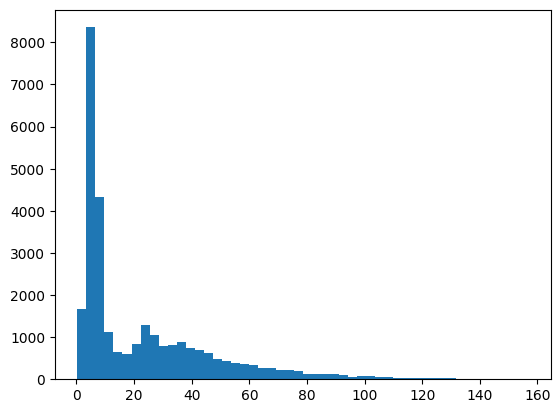

In [ ]:
#saving time variable(efs_time) in T and event/status variable (efs) in E
T = train_df["efs_time"]
E = train_df["efs"]

#histogram to get an overall sense of the distribution
plt.hist(T, bins=50)
plt.show()

# Fitting a non parametric model (Kaplan-Meier Curve)

"The graph shows the typical survival pattern after a stem cell transplant.\nThere's a high risk right after the transplant, but things stabilize after a while. The overall survival rate being around 45-46%.\nThis graph is a starting point for building a model to predict who might need extra care after their transplant."

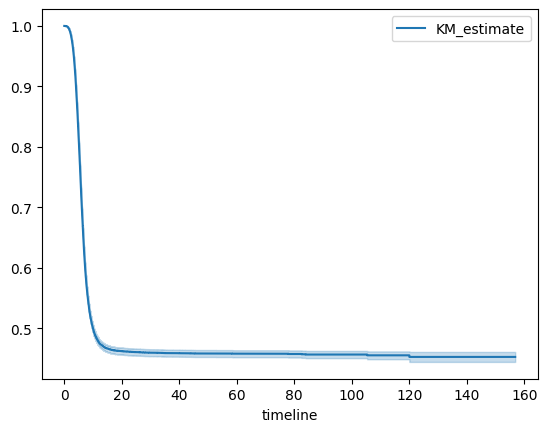

In [ ]:
#plotting a survival curve of the overall data using Kaplan-Maier Approach
kmf = KaplanMeierFitter()                     #Instantiate KaplanMeierFitter( ) class object
kmf.fit(durations = T, event_observed = E)    #use .fit( ) method and supply duration = T and event_observed = E
kmf.plot_survival_function()


'''The graph shows the typical survival pattern after a stem cell transplant.
There's a high risk right after the transplant, but things stabilize after a while. The overall survival rate being around 45-46%.
This graph is a starting point for building a model to predict who might need extra care after their transplant.'''

In [ ]:
kmf.median_survival_time_  #50% will survive or die after 9.98 months

9.98

In [ ]:
#Median Survival Time and Confidence Intervals
from lifelines.utils import median_survival_times
median_ = kmf.median_survival_time_
median_confidence_interval_ = median_survival_times(kmf.confidence_interval_)
print(median_)
print(median_confidence_interval_)

'''
Interpretation:

You can be 95% confident that the true median survival time for the population lies between 9.664 and 10.31 time units.
In simpler terms, if you were to repeat your study many times with different samples from the same population,
you'd expect the median survival time to fall within this range in 95% of those studies.
'''

9.98
     KM_estimate_lower_0.95  KM_estimate_upper_0.95
0.5                   9.664                   10.31


"\nInterpretation:\n\nYou can be 95% confident that the true median survival time for the population lies between 9.664 and 10.31 time units.\nIn simpler terms, if you were to repeat your study many times with different samples from the same population,\nyou'd expect the median survival time to fall within this range in 95% of those studies.\n"

In [ ]:
# Instantiate the CoxPHFitter with a penalizer
cph = CoxPHFitter(penalizer=0.01)  # Adjust the penalizer value as needed

# Fit the model with LASSO regularization
cph.fit(train_df, duration_col='efs_time', event_col='efs')

# Print the summary (coefficients will be shrunk)
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 28800 total observations, 13268 right-censored observations>
             duration col = 'efs_time'
                event col = 'efs'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 28800
number of events observed = 15532
   partial log-likelihood = -151572.57
         time fit was run = 2025-03-09 23:55:20 UTC

---
                                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                             
ID                                                   -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
dri_score                                             0.04      1.04      0.01            0.03            0.05                1.03                1.06
psych_disturb                                         0.03      1.03      0.01            0.00            0.05                1.00                1.06
cyto_score                                            0.05      1.05      0.00            0.04            0.06                1.04                1.06
diabetes                                              0.02      1.02      0.01           -0.01            0.05                0.99                1.05
hla_match_c_high                                     -0.05      0.95      0.02           -0.08           -0.02                0.92                0.98
hla_high_res_8                                        0.01      1.01      0.01           -0.00            0.03                1.00                1.03
arrhythmia                                            0.01      1.01      0.01           -0.02            0.04                0.98                1.04
hla_low_res_6                                         0.03      1.03      0.01            0.01            0.04                1.01                1.04
graft_type                                            0.10      1.10      0.04            0.03            0.17                1.03                1.18
vent_hist                                            -0.00      1.00      0.03           -0.07            0.06                0.93                1.06
renal_issue                                          -0.03      0.97      0.02           -0.06            0.00                0.94                1.00
pulm_severe                                           0.01      1.01      0.01           -0.01            0.04                0.99                1.04
hla_high_res_6                                        0.00      1.00      0.01           -0.02            0.02                0.98                1.02
cmv_status                                            0.02      1.02      0.01            0.01            0.03                1.01                1.03
hla_high_res_10                                       0.02      1.02      0.01           -0.00            0.04                1.00                1.04
hla_match_dqb1_high                                  -0.01      0.99      0.03           -0.07            0.05                0.93                1.05
hla_nmdp_6                                           -0.05      0.96      0.01           -0.07           -0.02                0.93                0.98
hla_match_c_low                                      -0.03      0.97      0.04           -0.11            0.04                0.90                1.04
rituximab                                             0.04      1.05      0.06           -0.07            0.15                0.94                1.17
hla_match_drb1_low                                    0.04      1.05      0.04           -0.03            0.12                0.97                1.13
hla_match_dqb1_low                                   -0.01      0.99      0.03           -0.

# Trying XGBoost to see if I can enhance the C-Index

In [ ]:
import pandas as pd

# Load dataset (assuming it's in a DataFrame called df)
event_counts = train_df["efs"].value_counts(normalize=True)
print(event_counts)


efs
1.0    0.539306
0.0    0.460694
Name: proportion, dtype: float64


In [ ]:
#Race data is one-hot encoded (each row has TRUE for one race and FALSE for others),
#checking imbalance requires counting how many times each race appears.

#Counts the number of TRUE values per race.
#Converts to a percentage to see representation.
race_columns = [
    "race_group_American Indian or Alaska Native",
    "race_group_Asian",
    "race_group_Black or African-American",
    "race_group_More than one race",
    "race_group_Native Hawaiian or other Pacific Islander",
    "race_group_White"
]

race_counts = train_df[race_columns].sum()  # Sum up TRUE values
race_percentages = (race_counts / len(train_df)) * 100  # Convert to %

print(race_counts)
print(race_percentages)

race_group_American Indian or Alaska Native             4790
race_group_Asian                                        4832
race_group_Black or African-American                    4795
race_group_More than one race                           4845
race_group_Native Hawaiian or other Pacific Islander    4707
race_group_White                                        4831
dtype: int64
race_group_American Indian or Alaska Native             16.631944
race_group_Asian                                        16.777778
race_group_Black or African-American                    16.649306
race_group_More than one race                           16.822917
race_group_Native Hawaiian or other Pacific Islander    16.343750
race_group_White                                        16.774306
dtype: float64


In [ ]:
#THIS SHOWED 0.68
import xgboost as xgb
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split

# Assuming 'df' is your DataFrame and 'survival_time' and 'event' are columns in df
# We will use 'survival_time' as the target variable
y = train_df['efs_time']

# Features: Use all columns except 'survival_time' and 'event'
X = train_df.drop(columns=['efs_time', 'efs'])

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #stratify=train_df['efs']

X.columns = [str(col).replace("[", "_").replace("]", "_").replace("<", "_") for col in X.columns]
X_train.columns = [str(col).replace("[", "_").replace("]", "_").replace("<", "_") for col in X_train.columns]
X_test.columns = [str(col).replace("[", "_").replace("]", "_").replace("<", "_") for col in X_test.columns]
X.columns = [str(col).replace("[", "_").replace("]", "_").replace("<", "_") for col in X.columns]

# Get event status (censoring indicator)
event = train_df['efs']
event_train = event[X_train.index]
event_test = event[X_test.index]

# Prepare the data for XGBoost, including lower and upper bounds
# For uncensored data, lower and upper bounds are the same (survival time)
# For censored data, upper bound is infinity (represented by np.inf)
lower_bound_train = y_train
upper_bound_train = np.where(event_train == 1, y_train, np.inf)
lower_bound_test = y_test
upper_bound_test = np.where(event_test == 1, y_test, np.inf)

dtrain = xgb.DMatrix(X_train)
dtrain.set_float_info('label_lower_bound', lower_bound_train)
dtrain.set_float_info('label_upper_bound', upper_bound_train)

dtest = xgb.DMatrix(X_test)
dtest.set_float_info('label_lower_bound', lower_bound_test)
dtest.set_float_info('label_upper_bound', upper_bound_test)


# Set XGBoost parameters, use the built-in Cox proportional hazards objective
params = {
    'objective': 'survival:aft',  # Use the built-in Cox PH objective
    'eval_metric': 'aft-nloglik',     # Use concordance index as eval metric
    'max_depth': 3,  # Tune hyperparameters
    'eta': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

# Train the model
model = xgb.train(params, dtrain, num_boost_round=1000,
                  early_stopping_rounds=10, evals=[(dtest, 'test')])

# Predict on the test set and calculate C-index
y_pred = model.predict(dtest)
c_index = concordance_index(y_test, y_pred, event_observed=event_test)  # Use y_test for C-index calculation
print(f"C-index with XGBoost: {c_index}")

[0]	test-aft-nloglik:7.45363
[1]	test-aft-nloglik:6.53138
[2]	test-aft-nloglik:5.78044
[3]	test-aft-nloglik:5.16955
[4]	test-aft-nloglik:4.67084
[5]	test-aft-nloglik:4.26405
[6]	test-aft-nloglik:3.93045
[7]	test-aft-nloglik:3.65708
[8]	test-aft-nloglik:3.43375
[9]	test-aft-nloglik:3.25106
[10]	test-aft-nloglik:3.10261
[11]	test-aft-nloglik:2.98054
[12]	test-aft-nloglik:2.88079
[13]	test-aft-nloglik:2.79877
[14]	test-aft-nloglik:2.73140
[15]	test-aft-nloglik:2.67693
[16]	test-aft-nloglik:2.63125
[17]	test-aft-nloglik:2.59386
[18]	test-aft-nloglik:2.56299
[19]	test-aft-nloglik:2.53733
[20]	test-aft-nloglik:2.51609
[21]	test-aft-nloglik:2.49908
[22]	test-aft-nloglik:2.48476
[23]	test-aft-nloglik:2.47283
[24]	test-aft-nloglik:2.46329
[25]	test-aft-nloglik:2.45505
[26]	test-aft-nloglik:2.44791
[27]	test-aft-nloglik:2.44189
[28]	test-aft-nloglik:2.43705
[29]	test-aft-nloglik:2.43323
[30]	test-aft-nloglik:2.42920
[31]	test-aft-nloglik:2.42562
[32]	test-aft-nloglik:2.42277
[33]	test-aft-nlogli

In [ ]:
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split


# Separate features (X) and survival data (y)
X = train_df.drop(columns=["efs_time", "efs"])  # Predictor variables
y = train_df[["efs_time", "efs"]]  # Survival outcome (time and censoring)

# Split data (Stratify by event to maintain censoring ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y["efs"]
)

# Check the shape
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (23040, 129)
Testing set size: (5760, 129)


# Will clean up in the morning (everything above here is the final code):

In [ ]:
#why aft over cox
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import pandas as pd

# Prepare Data
df = train_df.copy()  # Make a copy to avoid modifying the original DataFrame
df = df.drop(columns=['ID'])  # Drop non-relevant ID column if present

# Fit a Cox Model
cph = CoxPHFitter(penalizer = 0.1)
cph.fit(train_df, duration_col="efs_time", event_col="efs")

# Schoenfeld Residuals Test
results = proportional_hazard_test(cph, train_df, time_transform="rank")

# Display Results
print(results.summary)


                       test_statistic             p   -log2(p)
ID                           0.039308  8.428402e-01   0.246669
age_at_hct                  43.676657  3.873646e-11  34.587517
arrhythmia                  48.228450  3.793443e-12  37.939629
cardiac_No                   1.036829  3.085600e-01   1.696377
cardiac_Not done             1.858470  1.728015e-01   2.532812
...                               ...           ...        ...
tce_imm_match_P/P            1.335982  2.477439e-01   2.013079
tce_imm_match_Unknown        3.398006  6.527529e-02   3.937319
tce_match                    3.529843  6.027350e-02   4.052332
vent_hist                    0.010254  9.193428e-01   0.121325
year_hct                    32.706436  1.071818e-08  26.475365

[129 rows x 3 columns]


In [ ]:
# Assuming 'df' is your DataFrame and 'survival_time' and 'event' are columns in df
# We will use 'survival_time' as the target variable
y = train_df['efs_time']

# Features: Use all columns except 'survival_time' and 'event'
X = train_df.drop(columns=['efs_time', 'efs'])


In [ ]:
selected_features = ['ID', 'dri_score', 'psych_disturb', 'cyto_score', 'hla_match_c_high',
       'arrhythmia', 'hla_low_res_6', 'graft_type', 'pulm_severe',
       'cmv_status', 'hla_nmdp_6', 'cyto_score_detail',
       'conditioning_intensity', 'year_hct', 'in_vivo_tcd', 'tce_match',
       'hla_match_a_high', 'donor_age', 'hla_match_b_low', 'age_at_hct',
       'sex_match', 'comorbidity_score', 'karnofsky_score',
       'hla_match_drb1_high', 'tbi_status_No TBI', 'prod_type_BM',
       'prod_type_PB', 'ethnicity_Not Hispanic or Latino',
       'race_group_Black or African-American', 'race_group_More than one race',
       'tce_div_match_Unknown', 'cardiac_Yes', 'gvhd_proph_FK+ MMF +- others']

subset_df = train_df[selected_features + ['efs_time', 'efs']]  # Ensure time-to-event and event columns are included

# Fit Cox Model
cph = CoxPHFitter(penalizer=0.1)
cph.fit(subset_df, duration_col='efs_time', event_col='efs')

# Print Summary
cph.print_summary()

# Compute new C-index
new_c_index = cph.concordance_index_
print(f"New C-index: {new_c_index}")

#Brings it down

The Kaplan-Meier estimator estimates the survival function, providing insights into the median survival time and its confidence interval. The Cox Proportional Hazards model evaluates the effect of covariates on survival risk while accounting for censoring, and the inclusion of Lasso regularization helps prevent overfitting by penalizing less important predictors, leading to a more interpretable and robust model. This combination allows for better identification of significant covariates and their impact on survival outcomes. However, the Cox model struggles with non-proportional hazards or when covariates’ effects change over time.

The Kaplan-Meier estimator provides a non-parametric estimate of the survival function, allowing us to visualize survival probabilities over time and assess the median survival time. It is ideal for understanding the overall survival pattern of a group. The CoxPH model, on the other hand, builds on this by incorporating covariates, such as age or treatment type, to quantify their impact on survival. Together, these methods offer a comprehensive approach: Kaplan-Meier for descriptive analysis and CoxPH for deeper insights into the factors influencing survival.